In [1]:
SOURCE = "../2308.jpg"
ONNX_PATH = "../model/YOLO_int.onnx"

NC = 4
DFL_CH = 16
STRIDES = [8, 16, 32]

CONF_TH = 0.1

In [2]:
import onnxruntime as ort
from utils import util
import cv2
import numpy as np

# 載入模型
session = ort.InferenceSession(ONNX_PATH)

# 🔹 input 資訊
print("=== Inputs ===")
for inp in session.get_inputs():
    print("Name:", inp.name)
    print("Shape:", inp.shape)
    print("Type:", inp.type)

    # onnx, pytorch (B,C,H,W)
    IMG_W, IMG_H = inp.shape[2:]
    # xmodel, keras (B,H,W,C)
    # IMG_W, IMG_H = inp.shape[1:]
    
    print(f"INPUT IMG WH : ({IMG_W},{IMG_H})")

# 🔹 output 資訊
print("\n=== Outputs ===")
for out in session.get_outputs():
    print("Name:", out.name)
    print("Shape:", out.shape)
    print("Type:", out.type)

=== Inputs ===
Name: YOLO::input_0
Shape: [1, 3, 640, 640]
Type: tensor(float)
INPUT IMG WH : (640,640)

=== Outputs ===
Name: 1702
Shape: [1, 68, 80, 80]
Type: tensor(float)
Name: 1855
Shape: [1, 68, 40, 40]
Type: tensor(float)
Name: 2008
Shape: [1, 68, 20, 20]
Type: tensor(float)


## 前處理

In [3]:
def preprocess_image(img:cv2.Mat, input_size:int, channel_format='CHW'):
    """
    channel_format: 'CHW'(pt) or 'HWC'(xmodel) \n
    pt -> CHW \n
    xmodel -> HWC 
    """
    
    # img = cv2.imread(image_path)
    if img is None:
        print("Failed to read image, please check the path")
        return None

    resized_img, ratio, pad = util.resize(img, input_size)
    norm_img = util.norm(resized_img)

    # Convert channel format
    if channel_format == 'CHW':
        # (H, W, 3) -> (3, H, W)
        norm_img = norm_img.transpose(2, 0, 1)
        # Add batch dimension (3, H, W) -> (1, 3, H, W)
        norm_img = np.expand_dims(norm_img, axis=0)
    elif channel_format == 'HWC':
        # Keep (H, W, 3), add batch dimension -> (1, H, W, 3)
        norm_img = np.expand_dims(norm_img, axis=0)
    else:
        print(f"Invalid channel_format '{channel_format}', use 'CHW' or 'HWC'")
        return None

    return norm_img, ratio, pad

resize time (avg 100 runs): 0.000231s
norm time (avg 100 runs): 0.001216s
float2fix time (avg 100 runs): 0.000765s
fix2float time (avg 100 runs): 0.000356s


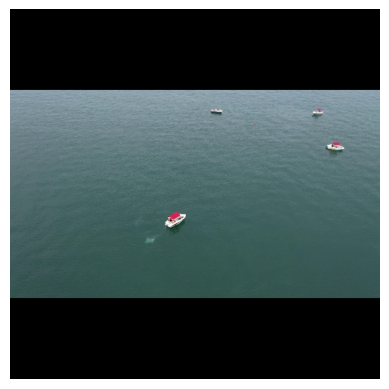

In [25]:
import time

frame = cv2.imread(SOURCE)

import matplotlib.pyplot as plt

# 執行20次取平均時間
N = 100

# resize
start = time.time()
for _ in range(N):
    resized_img, _, _ = util.resize(frame, input_size=IMG_W)
print(f"resize time (avg {N} runs): {(time.time()-start)/N:.6f}s")

# norm
start = time.time()
for _ in range(N):
    norm_img = util.norm_fma(resized_img)
    # norm_img = util.norm(resized_img)
print(f"norm time (avg {N} runs): {(time.time()-start)/N:.6f}s")

# float2fix
start = time.time()
for _ in range(N):
    fix_img = util.float2fix(norm_img, 6)
print(f"float2fix time (avg {N} runs): {(time.time()-start)/N:.6f}s")

# fix2float
# print(fix_img.shape, fix_img.dtype)
start = time.time()
for _ in range(N):
    fix_img = util.fix2float(fix_img, 2)
print(f"fix2float time (avg {N} runs): {(time.time()-start)/N:.6f}s")

resized_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)

plt.imshow(resized_img)
plt.axis('off')
plt.show()

In [6]:
orig_shape = frame.shape[:2]

onnx_input, ratio, pad = preprocess_image(img=frame, input_size=IMG_W, channel_format='CHW')

# onnx_input = util.float2fix(onnx_input,6)
# onnx_input = util.fix2float(onnx_input,6)
print(onnx_input.shape)

(1, 3, 640, 640)


## onnx 推理

In [7]:
import onnxruntime as ort

def run_inference(model_path:str, input_tensor:np.ndarray):
    """
    model_path  : path to .onnx model
    input_tensor: numpy array, shape [1, 3, H, W]
    """

    # Load ONNX model
    session = ort.InferenceSession(model_path, providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])

    # Get input / output name
    input_name  = session.get_inputs()[0].name
    output_names = [o.name for o in session.get_outputs()]

    # print(f"Input  name : {input_name}")
    # print(f"Input  shape: {session.get_inputs()[0].shape}")
    # print(f"Output names: {output_names}")

    # Run inference
    outputs = session.run(output_names, {input_name: input_tensor})

    return outputs

outputs = run_inference(ONNX_PATH, onnx_input)
print("outputs shape")
for out_node in outputs:
    print(out_node.shape)

outputs shape
(1, 68, 80, 80)
(1, 68, 40, 40)
(1, 68, 20, 20)


/opt/homebrew/Caskroom/miniforge/base/envs/thunderTiger/lib/python3.8/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


## 後處理

In [11]:
# from utils.post_process import YOLOPostProcessor

post_processor = util.YOLOPostProcessor(NC, DFL_CH, STRIDES)
# Post process out shape  (1,8,8400)
# 8 -> [cx, cy, w, h, cls_0, cls_1, cls_2, cls_3]
post_out = post_processor.__call__(outputs)
print(f"Post Process Result: {post_out.shape}")

#----------------- test ---------------------------
out_view = post_out.transpose(0,2,1)
scores = out_view[0,:,4:]
boxs = out_view[0,:,:4]

high_conf_cnt = 0
for score in scores:
    conf = score.max()
    cls = score.argmax()
    if conf>CONF_TH:
        high_conf_cnt+=1
print(f"Before NMS Boxs: {high_conf_cnt}")

Post Process Result: (1, 8, 8400)
Before NMS Boxs: 10


In [12]:
nms_out = util.non_max_suppression(post_out, confidence_threshold=CONF_TH)

result = nms_out[0]  # 第一張圖的結果
print(f"After NMS Detected boxes: {len(result)}")  # 或 result.shape[0]

for box in result:
    print(box[:])

After NMS Detected boxes: 2
[267.83633   352.35376   304.98636   377.26917     0.4378235   2.       ]
[5.5066040e+02 2.3342606e+02 5.7804858e+02 2.4475363e+02 1.8242553e-01
 2.0000000e+00]


In [13]:
if len(result) > 0:
    scale_result = np.zeros_like(result)
    scale_result[:,4:] = result[:,4:]
    scale_result[:, :4] = util.scale_boxes(result[:, :4], ratio, pad, orig_shape)

    for det in scale_result:
        x1, y1, x2, y2, score, class_id = det
        print(f"Class: {int(class_id)}, Score: {score:.4f}, Box: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")

Class: 2, Score: 0.4378, Box: [1607.0, 1274.1, 1829.9, 1423.6]
Class: 2, Score: 0.1824, Box: [3304.0, 560.6, 3468.3, 628.5]


## Visualize

In [14]:
CLASS_NAMES = ["cls0", "cls1", "cls2", "cls3"]

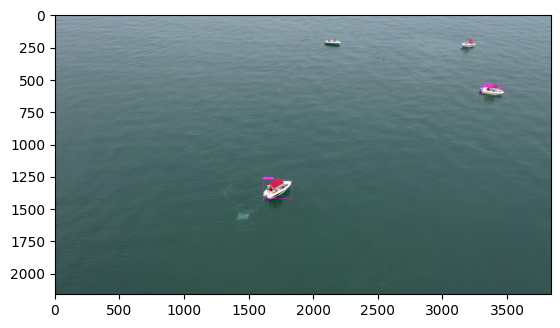

In [15]:
if len(result) > 0:
    scale_result = np.zeros_like(result)
    scale_result[:,4:] = result[:,4:]
    scale_result[:, :4] = util.scale_boxes(result[:, :4], ratio, pad, orig_shape)
    output_img = util.draw_boxes(frame, scale_result, CLASS_NAMES)
    cv2.imwrite("output.jpg", output_img)

    import matplotlib.pyplot as plt
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.show()